# Notebook 03 — Pricing par Monte Carlo

Pricing d'options par simulation stochastique. On simule des trajectoires de
prix sous mesure risque-neutre, puis on estime le prix d'une option comme
l'espérance actualisée du payoff.

## Exercice 1 — Simuler des trajectoires de GBM

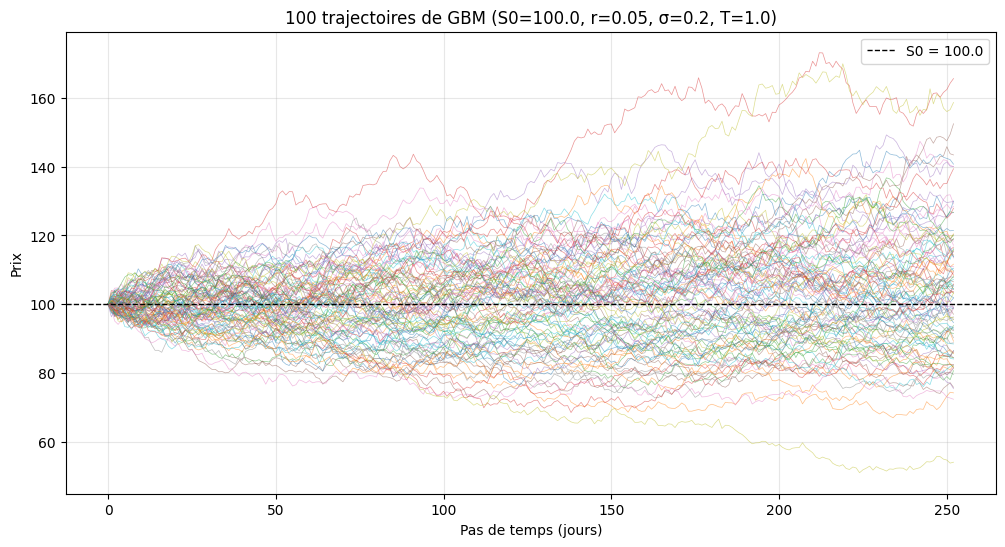

Prix final moyen  : 104.93
Théorie E[S_T]    : 105.13
Écart-type S_T    : 20.97
Min / Max         : 47.60 / 261.80


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Paramètres du marché
S0    = 100.0    # prix initial
r     = 0.05     # taux sans risque (5%)
sigma = 0.20     # volatilité (20%)
T     = 1.0      # maturité (1 an)

# Paramètres de simulation
n_steps = 252    # nombre de pas de temps (jours de bourse)
n_paths = 10000  # nombre de trajectoires simulées

dt = T / n_steps

## 1. Chocs aléatoires
Z = np.random.standard_normal(size=(n_paths, n_steps))

# 2. Incréments de log-prix
increments = (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z

# 3. Cumul le long du temps
log_paths = np.cumsum(increments, axis=1)

# 4. Prix = S0 * exp(log-cumul), avec la colonne initiale S0
paths = S0 * np.exp(log_paths)
paths = np.hstack([np.full((n_paths, 1), S0), paths])  # colonne S0 au début

# 5. Tracé des 100 premières trajectoires
plt.figure(figsize=(12, 6))
plt.plot(paths[:100].T, linewidth=0.5, alpha=0.5)
plt.axhline(S0, color='black', linestyle='--', linewidth=1, label=f'S0 = {S0}')
plt.title(f'100 trajectoires de GBM (S0={S0}, r={r}, σ={sigma}, T={T})')
plt.xlabel('Pas de temps (jours)')
plt.ylabel('Prix')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Statistiques du prix final
S_T = paths[:, -1]
print(f"Prix final moyen  : {S_T.mean():.2f}")
print(f"Théorie E[S_T]    : {S0*np.exp(r*T):.2f}")   # sous Q, E[S_T] = S0·e^(rT)
print(f"Écart-type S_T    : {S_T.std():.2f}")
print(f"Min / Max         : {S_T.min():.2f} / {S_T.max():.2f}")

## Exercice 2 — Pricer un call européen et comparer à Black-Scholes

On price un call européen par Monte Carlo (moyenne actualisée des payoffs),
puis on compare au prix analytique de Black-Scholes pour valider la méthode.

In [2]:
from scipy.stats import norm

# Strike de l'option
K = 100.0   # à la monnaie (at-the-money)

# ─── Pricing Monte Carlo ───
# 1. Payoff du call à maturité pour chaque trajectoire : max(S_T - K, 0)
payoffs = np.maximum(S_T - K, 0)

# 2. Prix MC = moyenne des payoffs actualisée
prix_mc = np.exp(-r*T) * payoffs.mean()

# 3. Erreur standard de l'estimation (intervalle de confiance)
erreur_std = np.exp(-r*T) * payoffs.std() / np.sqrt(n_paths)

# ─── Pricing Black-Scholes analytique ───
def black_scholes_call(S0, K, r, sigma, T):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

prix_bs = black_scholes_call(S0, K, r, sigma, T)

# ─── Comparaison ───
print("═══ Pricing d'un call européen ATM ═══\n")
print(f"  Monte Carlo    : {prix_mc:.4f}  ± {erreur_std:.4f}  (1 écart-type)")
print(f"  Black-Scholes  : {prix_bs:.4f}")
print(f"  Écart          : {abs(prix_mc - prix_bs):.4f}  "
      f"({abs(prix_mc-prix_bs)/prix_bs*100:.2f}%)")
print(f"\n  IC 95% : [{prix_mc - 1.96*erreur_std:.4f}, {prix_mc + 1.96*erreur_std:.4f}]")
print(f"  Black-Scholes dans l'IC 95% ? {abs(prix_mc-prix_bs) < 1.96*erreur_std}")

═══ Pricing d'un call européen ATM ═══

  Monte Carlo    : 10.2211  ± 0.1446  (1 écart-type)
  Black-Scholes  : 10.4506
  Écart          : 0.2295  (2.20%)

  IC 95% : [9.9377, 10.5045]
  Black-Scholes dans l'IC 95% ? True


### Bonus visualisation

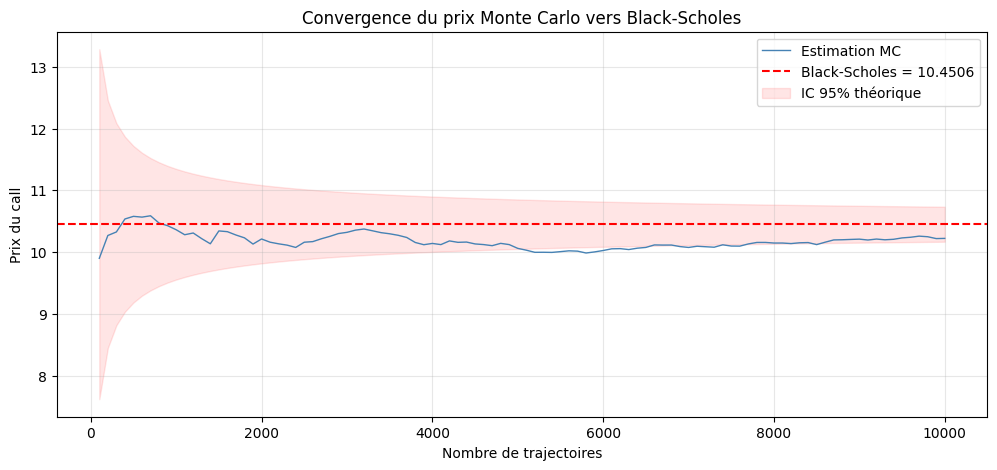

In [3]:
# Prix MC estimé en fonction du nombre de trajectoires utilisées
n_range = np.arange(100, n_paths+1, 100)
prix_cumule = np.exp(-r*T) * np.cumsum(payoffs)[n_range-1] / n_range

plt.figure(figsize=(12, 5))
plt.plot(n_range, prix_cumule, color='steelblue', linewidth=1, label='Estimation MC')
plt.axhline(prix_bs, color='red', linestyle='--', linewidth=1.5, label=f'Black-Scholes = {prix_bs:.4f}')
plt.fill_between(n_range,
                 prix_bs - 1.96*np.exp(-r*T)*payoffs.std()/np.sqrt(n_range),
                 prix_bs + 1.96*np.exp(-r*T)*payoffs.std()/np.sqrt(n_range),
                 color='red', alpha=0.1, label='IC 95% théorique')
plt.title('Convergence du prix Monte Carlo vers Black-Scholes')
plt.xlabel('Nombre de trajectoires')
plt.ylabel('Prix du call')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()